In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.legend_handler import HandlerTuple
import scienceplots
# Activate 'science' style
plt.style.use('science')
x = np.linspace(7, 17, 201)
benchmark = 79.20
benchmaks = np.ones_like(x)*benchmark
K = [8, 10, 12, 14, 16]
DGMS = [77.74, 77.97, 78.43, 78.62, 78.86]
Ours = [78.36, 78.44,78.54, 78.87, 78.92]

bechmarks_ResNet50=80.93*np.ones_like(x)
DGMS_ResNet50 = [79.8, 80.13, 80.3, 80.51, 80.68]
Ours_ResNet50 = [80.01, 80.35, 80.52, 80.61, 80.73]

x = np.linspace(7, 17, 201)
benchmark = 79.20
benchmaks = np.ones_like(x)*benchmark
K = [8, 10, 12, 14, 16]
DGMS = [77.74, 77.97, 78.43, 78.62, 78.86]
Ours = [78.36, 78.44,78.54, 78.87, 78.92]

bechmarks_ResNet50=80.93*np.ones_like(x)
DGMS_ResNet50 = [79.8, 80.13, 80.3, 80.51, 80.68]
Ours_ResNet50 = [80.01, 80.35, 80.52, 80.61, 80.73]

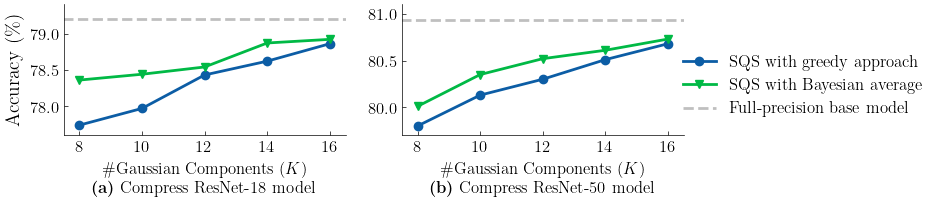

In [3]:

# Create side-by-side subplots
fig, axs = plt.subplots(1, 2, figsize=(8, 1.7))

# ---- Subplot (a): ResNet18 ----
axs[0].plot(x, benchmaks, linestyle='--', linewidth=2, alpha=0.5, color='gray')
l1a, = axs[0].plot(K, DGMS, linestyle='solid', marker='o', linewidth=2)
l2a, = axs[0].plot(K, Ours, linestyle='solid', marker='v', linewidth=2)
axs[0].set_yticks(np.arange(77.5, 79.6, 0.5))
axs[0].set_ylim((77.6, 79.4))
axs[0].set_xticks(np.arange(8, 16.5,2))
axs[0].set_xlim((7.5, 16.5))

axs[0].grid(False)
axs[0].set_xlabel(r"\#Gaussian Components ($K$)", fontsize=12)
axs[0].set_ylabel(r"Accuracy (\%)", fontsize=14)
# axs[0].set_title(r"\textbf{(a)} Compress ResNet-18 model", fontsize=12, pad=-6)
axs[0].spines['right'].set_visible(False)
axs[0].spines['top'].set_visible(False)
axs[0].tick_params(top=False, right=False)
axs[0].tick_params(which='minor', length=0, color='white')

# ---- Subplot (b): ResNet50 ----
axs[1].plot(x, bechmarks_ResNet50, linestyle='--', linewidth=2, alpha=0.5, color='gray')
l1b, = axs[1].plot(K, DGMS_ResNet50, linestyle='solid', marker='o', linewidth=2)
l2b, = axs[1].plot(K, Ours_ResNet50, linestyle='solid', marker='v', linewidth=2)
axs[1].set_yticks(np.arange(79.5, 81.21, 0.5))
axs[1].set_ylim((79.7, 81.1))
axs[1].set_xticks(np.arange(8, 16.5,2))
axs[1].set_xlim((7.5, 16.5))

axs[1].grid(False)
axs[1].set_xlabel(r"\#Gaussian Components ($K$)", fontsize=12)
# axs[1].set_title(r"\textbf{(b)} Compress ResNet-50 model", fontsize=12, pad=-6)
axs[1].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)
axs[1].tick_params(top=False, right=False)
axs[1].tick_params(which='minor', length=0, color='white')

axs[0].tick_params(labelsize=12)
axs[1].tick_params(labelsize=12)

##
axs[0].text(0.5, -0.4, r"\textbf{(a)} Compress ResNet-18 model", transform=axs[0].transAxes,
            ha='center', va='center', fontsize=12)
axs[1].text(0.5, -0.4, r"\textbf{(b)} Compress ResNet-50 model", transform=axs[1].transAxes,
            ha='center', va='center', fontsize=12)

# Custom 2-line legend entries
legend_items = [
    ((l1a,), "SQS with greedy approach"),
    ((l2a,), "SQS with Bayesian average"),
    ((axs[0].lines[0],), "Full-precision base model")
]

fig.legend(
    [h for h, _ in legend_items],
    [label for _, label in legend_items],
    handler_map={tuple: HandlerTuple(ndivide=None)},
    loc='center left',
    bbox_to_anchor=(0.88, 0.4),
    fontsize=12
)

# Save without white margin
plt.savefig("resnet18_50_cifar100_combined.pdf", format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()

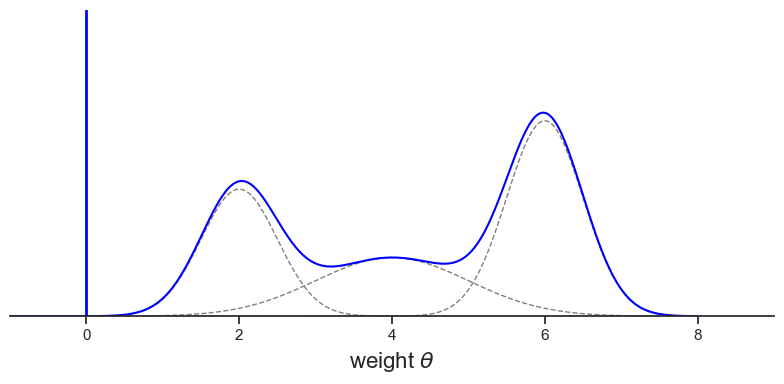

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


import seaborn
seaborn.set(style='ticks')

# Define the x-axis
x = np.linspace(-1, 8, 1000)

# Define the spike at zero
spike_weight = 0.3
spike = spike_weight * (x == 0).astype(float)

# Define the slab: a mixture of 3 Gaussians
slab_weight = 1 - spike_weight
means = [2, 4, 6]
stds = [0.5, 1.0, 0.5]
weights = [0.3, 0.4, 0.3]

# Adjust the weight of the first Gaussian component to make it lower
weights = [0.26, 0.24, 0.4]  # Lower the first component

# Recompute the slab with new weights
slab = sum(w * norm.pdf(x, loc=mu, scale=std) for w, mu, std in zip(weights, means, stds))
slab *= slab_weight

# Recompute the full spike-and-slab distribution
spike_and_slab = spike + slab

# Plot with updated weights
plt.figure(figsize=(8, 4))

# Plot each Gaussian component of the slab with updated weights
for w, mu, std in zip(weights, means, stds):
    component = w * norm.pdf(x, loc=mu, scale=std)
    component *= slab_weight
    plt.plot(x, component, linestyle='--', color='gray', linewidth=1)

# Plot slab (sum of components)
plt.plot(x, slab, label="Slab (GMM of 3 Gaussians)", linestyle='-', color='blue')


# plt.plot(x, spike_and_slab, label="Spike and Slab", color='black')

# Spike at zero (Dirac delta approximation)
plt.axvline(0, color='blue', linestyle='-', label="Spike at 0", linewidth=2)
ax = plt.gca()
ax.set_yticks([])
ax.set_ylabel("")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
# plt.title("Spike and Slab Distribution with GMM Slab (Adjusted Component Heights)")
plt.xlabel(r"weight $\theta$",fontsize=16)
# plt.ylabel("Density",fontsize=16)
plt.xlim(-1,9)
plt.ylim(0,0.35)
plt.grid(False)
# plt.legend()
plt.tight_layout()
# plt.show()
plt.savefig("spike-and-slab prior.pdf",format='pdf', bbox_inches='tight', pad_inches=0)
